In [64]:
import pandas as pd
import numpy as np

import seaborn as sns
from matplotlib import pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.feature_extraction import DictVectorizer
from sklearn.metrics import roc_auc_score
from sklearn.tree import export_text
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
import xgboost as xgb

%matplotlib inline

In [21]:
df = pd.read_csv('../../data/car_fuel_efficiency.csv')
df.columns = df.columns.str.lower().str.replace(' ', '_')

In [22]:
categorical_columns = list(df.dtypes[df.dtypes == 'object'].index)
numerical_columns = list(df.dtypes[df.dtypes != 'object'].index)
numerical_columns =  [x for x in numerical_columns if x != 'converted']

for col in categorical_columns:
    df[col] = df[col].fillna('NA')
    
for col in [numerical_columns]:
    df[col] = df[col].fillna(0)

In [23]:
df_full_train, df_test = train_test_split(df, test_size=0.2, random_state=1)
df_train, df_val = train_test_split(df_full_train, test_size=0.25, random_state=1)
df_train = df_train.reset_index(drop=True)
df_val = df_val.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)
y_train = df_train.fuel_efficiency_mpg.values
y_val = df_val.fuel_efficiency_mpg.values
y_test = df_test.fuel_efficiency_mpg.values
del(df_train['fuel_efficiency_mpg'])
del(df_test['fuel_efficiency_mpg'])
del(df_val['fuel_efficiency_mpg'])

In [44]:
dv = DictVectorizer(sparse=False)
train_dict = df_train.to_dict(orient='records')
val_dict = df_val.to_dict(orient='records')
X_train = dv.fit_transform(train_dict)
X_val = dv.transform(val_dict)

In [33]:
dt = DecisionTreeRegressor(max_depth=1)
dt.fit(X_train, y_train)

,criterion,'squared_error'
,splitter,'best'
,max_depth,1
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


In [34]:
print(export_text(dt, feature_names=list(dv.get_feature_names_out())))

|--- vehicle_weight <= 3022.11
|   |--- value: [16.88]
|--- vehicle_weight >  3022.11
|   |--- value: [12.94]



In [51]:
rf = RandomForestRegressor(n_estimators=10, random_state=1, n_jobs=-1)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_val)
rmse = np.sqrt(mean_squared_error(y_val, y_pred))
rmse


np.float64(0.4570712602619732)

In [54]:
scores = []

for n in range(10, 201, 10):
    rf = RandomForestRegressor(n_estimators=n, random_state=1)
    rf.fit(X_train, y_train)

    y_pred = rf.predict(X_val)
    rmse = np.round(np.sqrt(mean_squared_error(y_val, y_pred)), 3)
    
    scores.append((n, rmse))

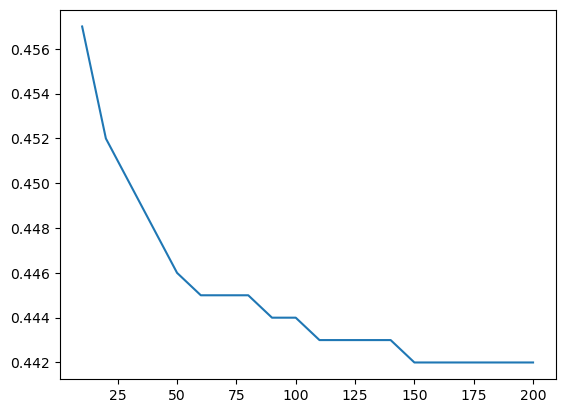

In [55]:
df_scores = pd.DataFrame(scores, columns=['n_estimators', 'rmse'])
plt.plot(df_scores.n_estimators, df_scores.rmse)

In [56]:
for max_depth in [10, 15, 20, 25]:
  scores = []
  for n in range(10, 201, 10):
    rf = RandomForestRegressor(n_estimators=n, random_state=1, max_depth=max_depth)
    rf.fit(X_train, y_train)

    y_pred = rf.predict(X_val)
    rmse = np.sqrt(mean_squared_error(y_val, y_pred))
    
    scores.append(rmse)
  mean_rmse = np.mean(scores)    
  print (max_depth, ': ', mean_rmse)

10 :  0.44177370392969184
15 :  0.4450240433962002
20 :  0.4459547840883615
25 :  0.445408466437377


In [59]:
rf = RandomForestRegressor(n_estimators=10, max_depth=20, random_state=1, n_jobs=-1)
rf.fit(X_train, y_train)
feature_importances = rf.feature_importances_
for feature, importance in zip(list(dv.get_feature_names_out()), feature_importances):
  print(f"{feature}: {importance:.4f}")

acceleration: 0.0115
drivetrain=All-wheel drive: 0.0004
drivetrain=Front-wheel drive: 0.0003
engine_displacement: 0.0033
fuel_type=Diesel: 0.0004
fuel_type=Gasoline: 0.0003
horsepower: 0.0160
model_year: 0.0032
num_cylinders: 0.0023
num_doors: 0.0016
origin=Asia: 0.0005
origin=Europe: 0.0005
origin=USA: 0.0006
vehicle_weight: 0.9592


In [65]:
features = list(dv.get_feature_names_out())
dtrain = xgb.DMatrix(X_train, label=y_train, feature_names=features)
dval = xgb.DMatrix(X_val, label=y_val, feature_names=features)

In [68]:
watchlist = [(dtrain, 'train'), (dval, 'val')]

xgb_params = {
    'eta': 0.3, 
    'max_depth': 6,
    'min_child_weight': 1,
    
    'objective': 'reg:squarederror',
    'nthread': 8,
    
    'seed': 1,
    'verbosity': 1,
}
model = xgb.train(xgb_params, dtrain, num_boost_round=10)

y_pred = model.predict(dval)
rmse = np.sqrt(mean_squared_error(y_val, y_pred))
print (rmse)

xgb_params['eta'] = 0.1
model = xgb.train(xgb_params, dtrain, num_boost_round=10)

y_pred = model.predict(dval)
rmse = np.sqrt(mean_squared_error(y_val, y_pred))
print (rmse)



0.4456395031860183
1.0200885118810736
